# English Routing Analysis (RQ2)

**Research question:** Do MoE routers develop age-correlated expert specialization in English without explicit demographic supervision?

**Models:**
- `adult_moe` — fine-tuned on adult speech only (routing baseline)
- `child_moe_lb_off` — fine-tuned on child speech, load balancing off
- `child_moe_lb_on` — fine-tuned on child speech, load balancing on

**Test sets:**
- LibriSpeech test-clean (adult English)
- MyST test (child English)
- YODAS2 English subset (domain control)

**Metrics:**
1. JSD — how different are adult vs child routing distributions?
2. Expert preference delta (Delta) — which experts drive the difference?
3. Pairwise cosine similarity — do experts compute different functions?

## Setup and imports

In [1]:
import contextlib
import io
import json
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import nemo.collections.asr as nemo_asr
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.spatial.distance import jensenshannon

sns.set_theme(style="whitegrid")

# --- Paths ---
ROUTING_DIR = Path("routing_outputs_en")
OUTPUT_DIR = Path("routing_outputs_en_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

ADULT_MOE_CSV = ROUTING_DIR / "adult_moe_routing.csv"
CHILD_MOE_LB_OFF_CSV = ROUTING_DIR / "child_moe_lb_off_routing.csv"
CHILD_MOE_LB_ON_CSV = ROUTING_DIR / "child_moe_lb_on_routing.csv"

YODAS_CSVS = {
    "adult_moe": ROUTING_DIR / "adult_moe_routing_yodas.csv",
    "child_moe_lb_off": ROUTING_DIR / "child_moe_lb_off_routing_yodas.csv",
    "child_moe_lb_on": ROUTING_DIR / "child_moe_lb_on_routing_yodas.csv",
}

# Cosine similarity (precomputed)
COSINE_NPZ = ROUTING_DIR / "expert_output_similarity.npz"

# --- Constants ---
MODEL_NAMES = ["adult_moe", "child_moe_lb_on", "child_moe_lb_off"]

MODEL_DISPLAY_NAMES = {
    "adult_moe": r"EN-MoE$_{LS}$",
    "child_moe_lb_on": r"EN-MoE$_{LB-on}$",
    "child_moe_lb_off": r"EN-MoE$_{LB-off}$",
}

def model_label(model_key: str) -> str:
    return MODEL_DISPLAY_NAMES.get(model_key, model_key)

NUM_LAYERS = 17
NUM_EXPERTS = 4
TOP_K = 2
N_BOOT = 1_000

EXPERT_PROB_COLS = [f"expert_{i}_prob" for i in range(NUM_EXPERTS)]

# --- Helpers ---
RNG = np.random.default_rng(42)


def jsd(p, q):
    """Jensen-Shannon Divergence.
    scipy.jensenshannon returns sqrt(JSD), so we square it."""
    return jensenshannon(p, q, base=2.0) ** 2


print("ROUTING_DIR:", ROUTING_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

/home/nvidia/miniconda3/envs/nemo_moe/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


ROUTING_DIR: routing_outputs_en
OUTPUT_DIR: routing_outputs_en_analysis


## Compute group-level routing distributions

For each (model, layer, age_group), sum expert probs weighted by utterance duration and normalize to get a 4-element distribution.

In [2]:
REQUIRED_COLS = [
    "utterance_id",
    "age_group",
    "dataset_source",
    "language",
    "layer_idx",
    "top1_expert",
    "top2_expert",
    "duration_sec",
    *EXPERT_PROB_COLS,
    "model",
]


def load_routing_csv(path: Path, name: str) -> pd.DataFrame | None:
    """Load one routing CSV and check required columns."""
    if not path.exists():
        print(f"WARNING: missing {name} at {path}")
        return None

    df = pd.read_csv(path)

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        print(f"WARNING: {name} missing columns: {missing}")

    print(f"  {name}: {df.shape[0]:,} rows, {df.shape[1]} cols")
    return df


print("Loading model routing CSVs...")
routing_dfs = {
    "adult_moe": load_routing_csv(ADULT_MOE_CSV, "adult_moe"),
    "child_moe_lb_off": load_routing_csv(CHILD_MOE_LB_OFF_CSV, "child_moe_lb_off"),
    "child_moe_lb_on": load_routing_csv(CHILD_MOE_LB_ON_CSV, "child_moe_lb_on"),
}


print("\nLoading domain-control routing CSVs...")
yodas_dfs = {}
for name, path in YODAS_CSVS.items():
    yodas_dfs[name] = load_routing_csv(path, f"yodas_{name}")


print("\n--- Sanity check: main routing files ---")
for name, df in routing_dfs.items():
    if df is None or df.empty:
        print(f"  {name}: missing or empty")
        continue

    n_utt = df["utterance_id"].nunique()
    n_layers = df["layer_idx"].nunique()
    groups = sorted(df["age_group"].dropna().unique())
    datasets = sorted(df["dataset_source"].dropna().unique())

    print(
        f"  {name}: {n_utt:,} utterances, "
        f"{n_layers} layers, groups={groups}, datasets={datasets}"
)


print("\n--- Sanity check: domain-control routing files ---")
for name, df in yodas_dfs.items():
    if df is None or df.empty:
        print(f"  {name}: missing or empty")
        continue

    n_utt = df["utterance_id"].nunique()
    n_layers = df["layer_idx"].nunique()
    groups = sorted(df["age_group"].dropna().unique()) if "age_group" in df.columns else []
    datasets = sorted(df["dataset_source"].dropna().unique()) if "dataset_source" in df.columns else []

    print(
        f"  {name}: {n_utt:,} utterances, "
        f"{n_layers} layers, groups={groups}, datasets={datasets}"
)


def weighted_distribution(group_df: pd.DataFrame) -> np.ndarray | None:
    """
    Duration-weighted routing distribution from a group of utterances.

    Output:
        A 4-element probability vector over experts.
    """
    if group_df is None or group_df.empty:
        return None

    probs = group_df[EXPERT_PROB_COLS].values.astype(float)

    if "duration_sec" in group_df.columns:
        weights = group_df["duration_sec"].values.astype(float)
        totals = (probs * weights[:, None]).sum(axis=0)
    else:
        totals = probs.sum(axis=0)

    denom = totals.sum()
    if denom == 0:
        return np.zeros(NUM_EXPERTS)

    return totals / denom


def build_age_distributions(routing_dfs: dict[str, pd.DataFrame | None]) -> dict:
    """
    Build:
        distributions[model][layer][age_group] = np.array(NUM_EXPERTS)
    """
    out = {}

    for model_name, df in routing_dfs.items():
        if df is None or df.empty:
            out[model_name] = {}
            continue

        model_dist = {}

        for layer_idx, layer_df in df.groupby("layer_idx"):
            model_dist[int(layer_idx)] = {}
            for age_group, group_df in layer_df.groupby("age_group"):
                model_dist[int(layer_idx)][age_group] = weighted_distribution(group_df)

        out[model_name] = model_dist

    return out


distributions = build_age_distributions(routing_dfs)


print("\n--- Distribution check ---")
for name, model_dist in distributions.items():
    if not model_dist:
        print(f"  {name}: no distributions")
        continue

    layer0 = sorted(model_dist.keys())[0]
    group0 = sorted(model_dist[layer0].keys())[0]
    vec = model_dist[layer0][group0]

    print(
        f"  {name}, layer {layer0}, {group0}: "
        f"{np.round(vec, 4)}  (sum={vec.sum():.6f})"
)

Loading model routing CSVs...
  adult_moe: 268,413 rows, 14 cols
  child_moe_lb_off: 268,413 rows, 14 cols
  child_moe_lb_on: 268,413 rows, 14 cols

Loading domain-control routing CSVs...
  yodas_adult_moe: 22,100 rows, 14 cols
  yodas_child_moe_lb_off: 22,100 rows, 14 cols
  yodas_child_moe_lb_on: 22,100 rows, 14 cols

--- Sanity check: main routing files ---
  adult_moe: 15,789 utterances, 17 layers, groups=['adult', 'child'], datasets=['librispeech', 'myst']
  child_moe_lb_off: 15,789 utterances, 17 layers, groups=['adult', 'child'], datasets=['librispeech', 'myst']
  child_moe_lb_on: 15,789 utterances, 17 layers, groups=['adult', 'child'], datasets=['librispeech', 'myst']

--- Sanity check: domain-control routing files ---
  adult_moe: 1,300 utterances, 17 layers, groups=['adult'], datasets=['yodas']
  child_moe_lb_off: 1,300 utterances, 17 layers, groups=['adult'], datasets=['yodas']
  child_moe_lb_on: 1,300 utterances, 17 layers, groups=['adult'], datasets=['yodas']

--- Distribu

## JSD with bootstrap confidence intervals

Headline figure: where in the encoder does routing diverge between adult and child speech?

1. Compute observed JSD per model per layer
2. Duration-match adult and child pools (once)
3. Bootstrap 1,000 resamples to get 95% CIs
4. Plot JSD lines with shaded CI bands

In [ ]:
def model_label(model_key: str) -> str:
    """Return thesis/report display label for a model key."""
    return MODEL_DISPLAY_NAMES.get(model_key, model_key)


def greedy_duration_match(
    df: pd.DataFrame, target_dur: float, rng: np.random.Generator
) -> pd.DataFrame:
    """Subsample utterances without replacement to match a target duration."""
    idx = df.index.to_numpy().copy()
    rng.shuffle(idx)

    total = 0.0
    picked = []

    for i in idx:
        total += float(df.loc[i, "duration_sec"])
        picked.append(i)

        if total >= target_dur:
            break

    return df.loc[picked]


def layer_distributions(df: pd.DataFrame) -> dict[int, np.ndarray]:
    """Compute routing distribution per layer from a set of utterances."""
    out = {}

    for layer_idx, layer_df in df.groupby("layer_idx"):
        out[int(layer_idx)] = weighted_distribution(layer_df)

    return out


# --- Step 1: observed JSD ---
jsd_observed = {}  # model -> pd.DataFrame(layer, jsd)

for name, model_dist in distributions.items():
    rows = []

    for layer in range(NUM_LAYERS):
        ld = model_dist.get(layer, {})
        adult = ld.get("adult")
        child = ld.get("child")

        if adult is None or child is None:
            rows.append({"layer": layer, "jsd": np.nan})
        else:
            rows.append({"layer": layer, "jsd": jsd(adult, child)})

    jsd_observed[name] = pd.DataFrame(rows)


# --- Step 2 + 3: bootstrap CIs ---
jsd_ci = {}  # model -> pd.DataFrame(layer, ci_low, ci_high)

for name, df in routing_dfs.items():
    if df is None or df.empty:
        continue

    adult_all = df[df["age_group"] == "adult"]
    child_all = df[df["age_group"] == "child"]

    if adult_all.empty or child_all.empty:
        continue

    # Duration-match once outside the bootstrap loop
    adult_dur = float(adult_all["duration_sec"].sum())
    child_dur = float(child_all["duration_sec"].sum())

    if adult_dur >= child_dur:
        adult_pool = greedy_duration_match(adult_all, child_dur, RNG)
        child_pool = child_all
    else:
        child_pool = greedy_duration_match(child_all, adult_dur, RNG)
        adult_pool = adult_all

    n_adult = len(adult_pool)
    n_child = len(child_pool)

    adult_pool_idx = adult_pool.index.to_numpy()
    child_pool_idx = child_pool.index.to_numpy()

    # Bootstrap
    boot_jsd = np.full((N_BOOT, NUM_LAYERS), np.nan)

    for b in range(N_BOOT):
        a_idx = RNG.choice(adult_pool_idx, size=n_adult, replace=True)
        c_idx = RNG.choice(child_pool_idx, size=n_child, replace=True)

        a_dists = layer_distributions(adult_pool.loc[a_idx])
        c_dists = layer_distributions(child_pool.loc[c_idx])

        for layer in range(NUM_LAYERS):
            a = a_dists.get(layer)
            c = c_dists.get(layer)

            if a is not None and c is not None:
                boot_jsd[b, layer] = jsd(a, c)

    ci_rows = []

    for layer in range(NUM_LAYERS):
        vals = boot_jsd[:, layer]
        vals = vals[~np.isnan(vals)]

        if vals.size == 0:
            ci_rows.append(
                {
                    "layer": layer,
                    "ci_low": np.nan,
                    "ci_high": np.nan,
                }
            )
        else:
            ci_rows.append(
                {
                    "layer": layer,
                    "ci_low": float(np.percentile(vals, 2.5)),
                    "ci_high": float(np.percentile(vals, 97.5)),
                }
            )

    jsd_ci[name] = pd.DataFrame(ci_rows)
    print(f"  Bootstrap done for {model_label(name)}")


# --- Step 4: plot ---
fig, ax = plt.subplots(figsize=(8, 4))

for name in MODEL_NAMES:
    obs = jsd_observed.get(name)
    ci = jsd_ci.get(name)

    if obs is None:
        continue

    ax.plot(
        obs["layer"],
        obs["jsd"],
        marker="o",
        label=model_label(name),
    )

    if ci is not None:
        ax.fill_between(
            ci["layer"],
            ci["ci_low"],
            ci["ci_high"],
            alpha=0.15,
        )

ax.set_xlabel("Layer")
ax.set_ylabel("JSD (adult vs child)")
ax.set_title("Routing divergence between adult and child speech")
ax.set_xticks(range(NUM_LAYERS))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "jsd_with_bootstrap_ci.png", dpi=300)
plt.show()

## Expert preference delta heatmap

Delta_e = child_load_e - adult_load_e, where load = prob * top_k.
Shows which experts are child-preferred (red) or adult-preferred (blue) at each layer.

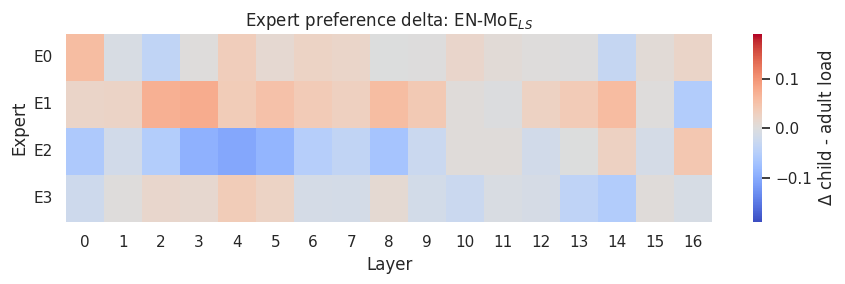

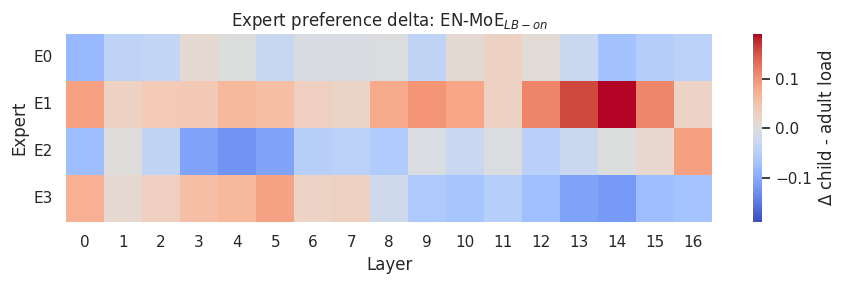

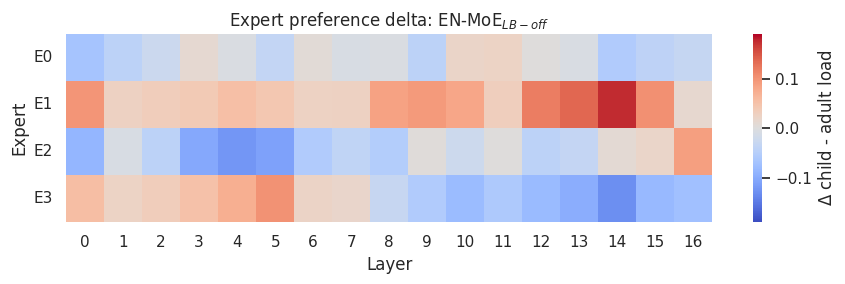

In [ ]:
delta_by_model = {}

for name, model_dist in distributions.items():
    mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)

    for layer in range(NUM_LAYERS):
        ld = model_dist.get(layer, {})
        adult = ld.get("adult")
        child = ld.get("child")

        if adult is None or child is None:
            continue

        mat[:, layer] = (child - adult) * TOP_K

    delta_by_model[name] = mat


# Shared symmetric color scale across all models
max_abs = max(
    (np.nanmax(np.abs(m)) for m in delta_by_model.values()),
    default=0.0,
)

if max_abs == 0:
    max_abs = 1e-6


for name in MODEL_NAMES:
    mat = delta_by_model.get(name)

    if mat is None:
        continue

    fig, ax = plt.subplots(figsize=(9, 3))

    sns.heatmap(
        mat,
        cmap="coolwarm",
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        ax=ax,
        cbar_kws={"label": r"$\Delta$ child - adult load"},
    )

    ax.set_xlabel("Layer")
    ax.set_ylabel("Expert")

    # Changed: use thesis/report model name instead of raw internal key
    ax.set_title(f"Expert preference delta: {model_label(name)}")

    ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
    ax.set_xticklabels(range(NUM_LAYERS))

    ax.set_yticks(np.arange(NUM_EXPERTS) + 0.5)
    ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0)

    plt.tight_layout()

    # Keep filename using raw key so files do not overwrite each other
    plt.savefig(OUTPUT_DIR / f"delta_heatmap_{name}.png", dpi=300)

    plt.show()

## Functional specialization - cosine similarity

At peak JSD layers (5 and 14), all 4 experts are evaluated on the same input frames (router bypassed). Pairwise cosine similarity between expert outputs shows whether experts compute different transformations.
Lower similarity after child fine-tuning suggests experts became more functionally specialized.
Paths to precomputed matrices can be updated to actual file locations.

Computing cosine similarity for EN-MoE$_{LS}$


[NeMo W 2026-06-09 09:58:42 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-06-09 09:58:42 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
[NeMo W 2026-06-09 09:58:42 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-06-09 09:58:42 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is

Computing cosine similarity for EN-MoE$_{LB-on}$


[NeMo W 2026-06-09 10:00:39 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-06-09 10:00:39 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
[NeMo W 2026-06-09 10:00:39 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-06-09 10:00:39 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is

Computing cosine similarity for EN-MoE$_{LB-off}$


[NeMo W 2026-06-09 10:02:04 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-06-09 10:02:04 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
[NeMo W 2026-06-09 10:02:04 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-06-09 10:02:04 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is

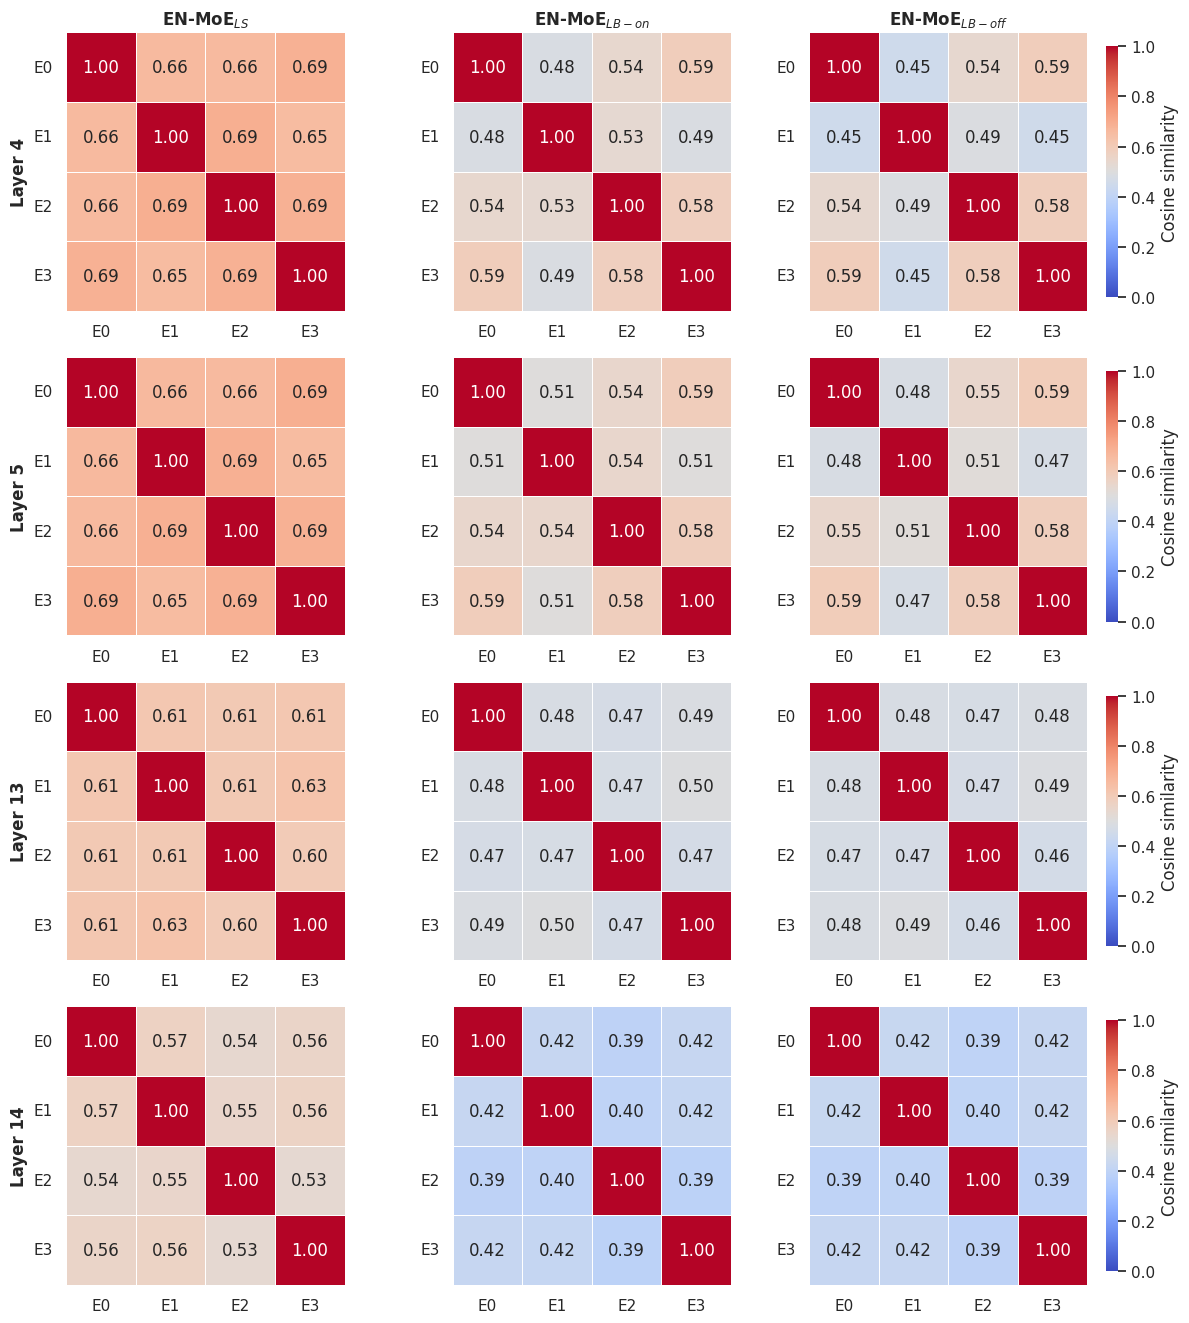

In [ ]:
COSINE_LAYERS = [4, 5, 13, 14]

# Use the same report/thesis order as the WER table:
# EN-MoE_LS, EN-MoE_LB-on, EN-MoE_LB-off
COSINE_MODELS = ["adult_moe", "child_moe_lb_on", "child_moe_lb_off"]

MODEL_FILES = {
    "adult_moe": "en_adult_moe.nemo",
    "child_moe_lb_on": "en_child_moe_lb_on.nemo",
    "child_moe_lb_off": "en_child_moe_lb_off.nemo",
}

# Display names for figure titles
MODEL_DISPLAY_NAMES = {
    "adult_moe": r"EN-MoE$_{LS}$",
    "child_moe_lb_on": r"EN-MoE$_{LB-on}$",
    "child_moe_lb_off": r"EN-MoE$_{LB-off}$",
}

def model_label(model_key: str) -> str:
    return MODEL_DISPLAY_NAMES.get(model_key, model_key)


MODEL_DIR = Path("/lp-dev/amelia/inclusive-asr-moe/final_weights")
LIBRISPEECH_MANIFEST = Path("/data/librispeech_nemo/test_clean.json")

DEVICE = "cuda"
NUM_EXPERTS = 4
N_COSINE_UTTERANCES = 200
MAX_FRAMES_PER_LAYER = 20000

COSINE_OUT = OUTPUT_DIR / "expert_output_similarity_L4_L5_L13_L14.npz"


def load_audio_paths(manifest_path, n):
    paths = []

    with open(manifest_path, "r", encoding="utf-8") as f:
        for line in f:
            if len(paths) >= n:
                break

            row = json.loads(line)
            p = row.get("audio_filepath")

            if p and os.path.exists(p):
                paths.append(p)

    return paths


def flatten_hidden(x):
    """
    Convert hidden tensor to (frames, hidden_dim).
    Keeps the final dimension as the feature dimension.
    """
    if isinstance(x, (tuple, list)):
        x = x[0]

    if not torch.is_tensor(x):
        return None

    x = x.detach().float()

    if x.ndim == 1:
        x = x[None, :]
    elif x.ndim == 2:
        pass
    elif x.ndim >= 3:
        x = x.reshape(-1, x.shape[-1])

    return x


def collect_feedforward_inputs(model, audio_paths, layers, device):
    """
    Collect the inputs to selected feed_forward blocks.
    """
    model.eval()
    model = model.to(device)

    collected = {layer: [] for layer in layers}
    hooks = []

    def make_hook(layer):
        def hook(module, inputs, output):
            if len(inputs) == 0:
                return

            x = flatten_hidden(inputs[0])

            if x is not None and x.numel() > 0:
                collected[layer].append(x.cpu())

        return hook

    for layer in layers:
        ff = model.encoder.layers[layer].feed_forward
        hooks.append(ff.register_forward_hook(make_hook(layer)))

    try:
        with torch.no_grad():
            for audio_path in audio_paths:
                try:
                    model.transcribe([audio_path], batch_size=1, verbose=False)
                except Exception:
                    continue
    finally:
        for h in hooks:
            h.remove()

    return collected


def apply_one_expert(ff, x, expert_idx):
    """
    Manually apply expert e to x.

    For this model:
      w1[e]: (2048, 512)
      w2[e]: (512, 2048)

    Therefore:
      x:      (frames, 512)
      hidden: x @ w1[e].T -> (frames, 2048)
      output: hidden @ w2[e].T -> (frames, 512)
    """
    w1 = ff.w1[expert_idx]
    w2 = ff.w2[expert_idx]

    h = x @ w1.T
    h = ff.activation(h)
    y = h @ w2.T

    return y


def cosine_matrix_for_layer(ff, inputs_list, num_experts=4, max_frames=20000):
    """
    Compute expert-output cosine matrix for one layer.

    This computes framewise cosine similarity and then averages over frames.
    That is better than cosine(mean output vectors), because cosine(mean outputs)
    can inflate similarity when experts share a common output direction.
    """
    if len(inputs_list) == 0:
        return np.full((num_experts, num_experts), np.nan)

    x = torch.cat(inputs_list, dim=0).to(ff.w1.device)

    # Subsample frames deterministically to keep computation manageable.
    if x.shape[0] > max_frames:
        idx = torch.linspace(0, x.shape[0] - 1, max_frames).long().to(x.device)
        x = x[idx]

    expert_outputs = []

    with torch.no_grad():
        for e in range(num_experts):
            y = apply_one_expert(ff, x, e)
            y = torch.nn.functional.normalize(y.float(), p=2, dim=-1)
            expert_outputs.append(y)

    mat = np.full((num_experts, num_experts), np.nan)

    with torch.no_grad():
        for i in range(num_experts):
            for j in range(num_experts):
                cos_per_frame = (expert_outputs[i] * expert_outputs[j]).sum(dim=-1)
                mat[i, j] = float(cos_per_frame.mean().detach().cpu())

    return mat


audio_paths = load_audio_paths(LIBRISPEECH_MANIFEST, N_COSINE_UTTERANCES)
cosine_mats = {}

# Reduce logging noise as much as possible.
logging.getLogger("nemo_logger").setLevel(logging.ERROR)
logging.getLogger("nemo").setLevel(logging.ERROR)

for model_name in COSINE_MODELS:
    model_path = MODEL_DIR / MODEL_FILES[model_name]

    print(f"Computing cosine similarity for {model_label(model_name)}")

    # NeMo still prints some restore logs; suppress stdout/stderr during restore.
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        model = nemo_asr.models.EncDecCTCModelBPE.restore_from(
            str(model_path),
            map_location=DEVICE,
        )

    model = model.to(DEVICE)
    model.eval()

    ff_inputs = collect_feedforward_inputs(
        model=model,
        audio_paths=audio_paths,
        layers=COSINE_LAYERS,
        device=DEVICE,
    )

    for layer in COSINE_LAYERS:
        ff = model.encoder.layers[layer].feed_forward

        cosine_mats[f"{model_name}_L{layer}"] = cosine_matrix_for_layer(
            ff=ff,
            inputs_list=ff_inputs[layer],
            num_experts=NUM_EXPERTS,
            max_frames=MAX_FRAMES_PER_LAYER,
        )

    del model
    torch.cuda.empty_cache()

np.savez(COSINE_OUT, **cosine_mats)


# --- Plot cosine similarity grid ---
cmap = "coolwarm"
vmin = 0.0
vmax = 1.0

n_rows = len(COSINE_LAYERS)
n_cols = len(COSINE_MODELS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.1 * n_cols, 3.35 * n_rows),
    sharex=False,
    sharey=False,
)

if n_rows == 1:
    axes = np.array([axes])

if n_cols == 1:
    axes = axes[:, None]

for r, layer in enumerate(COSINE_LAYERS):
    for c, model_name in enumerate(COSINE_MODELS):
        ax = axes[r, c]
        key = f"{model_name}_L{layer}"
        mat = cosine_mats[key]

        labels = [f"E{i}" for i in range(NUM_EXPERTS)]
        show_cbar = c == n_cols - 1

        sns.heatmap(
            mat,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            square=True,
            annot=True,
            fmt=".2f",
            linewidths=0.4,
            linecolor="white",
            ax=ax,
            xticklabels=labels,
            yticklabels=labels,
            cbar=show_cbar,
            cbar_kws={
                "label": "Cosine similarity",
                "shrink": 0.9,
                "pad": 0.05,
            },
        )

        # Changed: use thesis/report model names instead of raw keys
        if r == 0:
            ax.set_title(
                model_label(model_name),
                fontsize=12,
                fontweight="bold",
            )
        else:
            ax.set_title("")

        if c == 0:
            ax.set_ylabel(
                f"Layer {layer}",
                fontsize=12,
                fontweight="bold",
            )
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "cosine_similarity_grid_L4_L5_L13_L14.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Domain control

YODAS2 = adult English from YouTube (different domain from LibriSpeech).
If routing reflects age (not recording conditions), the two adult groups should route similarly despite different domains.
Three JSD curves:
- LibriSpeech vs MyST (age difference)
- LibriSpeech vs YODAS (domain difference, same age)
- MyST vs YODAS (age + domain difference)


=== EN-MoE$_{LS}$ ===
LibriSpeech rows: 44540 | utterances: 2620
MyST rows: 223873 | utterances: 13169
YODAS rows: 22100 | utterances: 1300

=== EN-MoE$_{LB-on}$ ===
LibriSpeech rows: 44540 | utterances: 2620
MyST rows: 223873 | utterances: 13169
YODAS rows: 22100 | utterances: 1300

=== EN-MoE$_{LB-off}$ ===
LibriSpeech rows: 44540 | utterances: 2620
MyST rows: 223873 | utterances: 13169
YODAS rows: 22100 | utterances: 1300


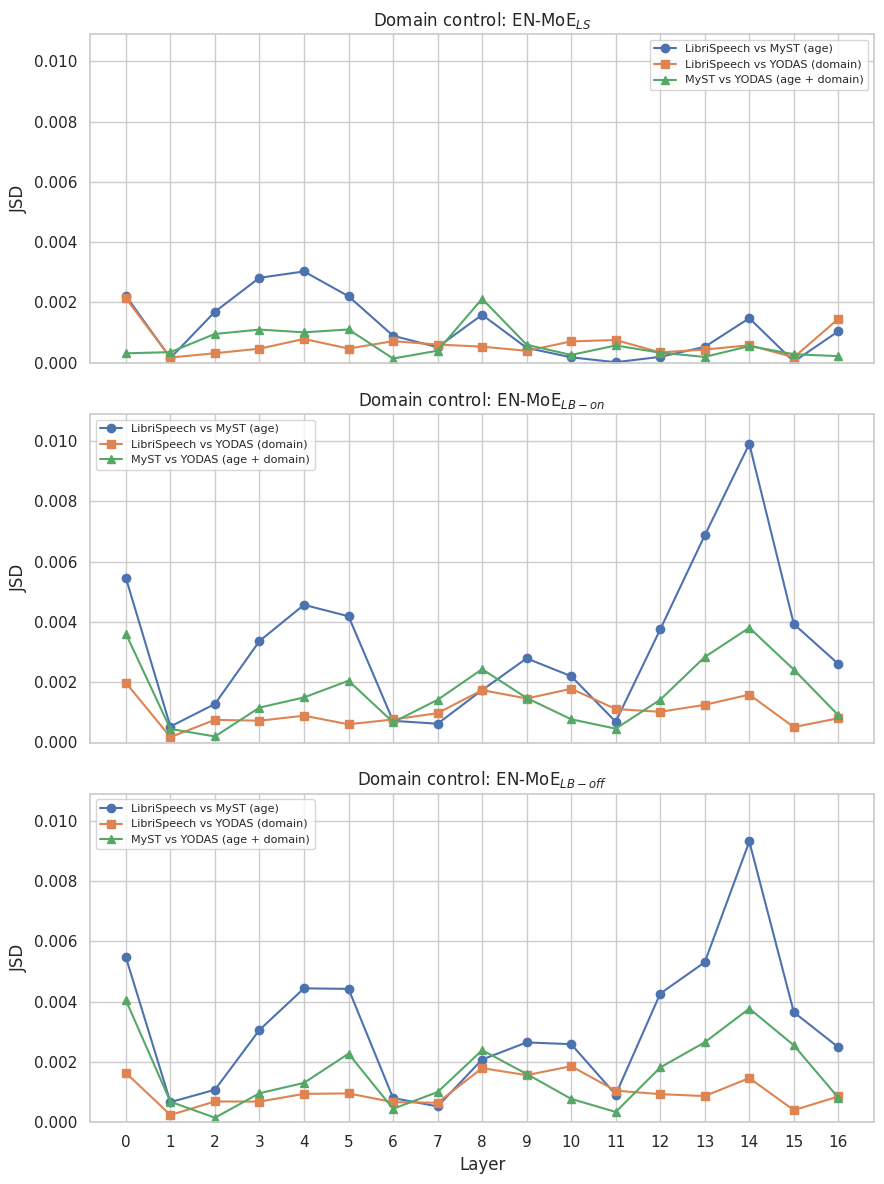

            model        model_key  peak_jsd_layer  peak_jsd  child_preferred_expert  delta_at_peak   ci_low  ci_high  n_layers_ci_above_zero
    EN-MoE$_{LS}$        adult_moe               4  0.003030                       1         0.0363 0.002815 0.003154                      17
 EN-MoE$_{LB-on}$  child_moe_lb_on              14  0.009908                       1         0.1898 0.009813 0.011152                      17
EN-MoE$_{LB-off}$ child_moe_lb_off              14  0.009318                       1         0.1764 0.008357 0.009608                      17


In [ ]:
def jsd_curve(dist_a: dict, dist_b: dict) -> pd.DataFrame:
    rows = []

    for layer in range(NUM_LAYERS):
        a = dist_a.get(layer)
        b = dist_b.get(layer)

        val = jsd(a, b) if (a is not None and b is not None) else np.nan
        rows.append({"layer": layer, "jsd": val})

    return pd.DataFrame(rows)


domain_results = {}
global_max_jsd = 0.0


# --- First pass: compute all curves ---
for model_name in MODEL_NAMES:
    model_df = routing_dfs.get(model_name)
    yodas_df = yodas_dfs.get(model_name)

    if model_df is None or model_df.empty:
        print(f"Missing {model_label(model_name)} routing data; skipping.")
        continue

    if yodas_df is None or yodas_df.empty:
        print(f"Missing {model_label(model_name)} YODAS data; skipping.")
        continue

    lib_df = model_df[
        (model_df["age_group"] == "adult")
        & (model_df["dataset_source"] == "librispeech")
    ]

    myst_df = model_df[
        (model_df["age_group"] == "child")
        & (model_df["dataset_source"] == "myst")
    ]

    if "age_group" in yodas_df.columns:
        yodas_sub_df = yodas_df[yodas_df["age_group"] == "adult"]
    else:
        yodas_sub_df = yodas_df

    print(f"\n=== {model_label(model_name)} ===")
    print(
        "LibriSpeech rows:",
        len(lib_df),
        "| utterances:",
        lib_df["utterance_id"].nunique(),
    )
    print(
        "MyST rows:",
        len(myst_df),
        "| utterances:",
        myst_df["utterance_id"].nunique(),
    )
    print(
        "YODAS rows:",
        len(yodas_sub_df),
        "| utterances:",
        yodas_sub_df["utterance_id"].nunique(),
    )

    if lib_df.empty or myst_df.empty or yodas_sub_df.empty:
        print(f"One subset is empty for {model_label(model_name)}; skipping.")
        continue

    lib_dist = layer_distributions(lib_df)
    myst_dist = layer_distributions(myst_df)
    yodas_dist = layer_distributions(yodas_sub_df)

    jsd_lib_myst = jsd_curve(lib_dist, myst_dist)
    jsd_lib_yodas = jsd_curve(lib_dist, yodas_dist)
    jsd_myst_yodas = jsd_curve(myst_dist, yodas_dist)

    domain_results[model_name] = {
        "lib_myst": jsd_lib_myst,
        "lib_yodas": jsd_lib_yodas,
        "myst_yodas": jsd_myst_yodas,
    }

    model_max = np.nanmax(
        [
            jsd_lib_myst["jsd"].max(),
            jsd_lib_yodas["jsd"].max(),
            jsd_myst_yodas["jsd"].max(),
        ]
    )

    global_max_jsd = max(global_max_jsd, model_max)


# Shared y-axis upper bound with a little padding
YMAX = global_max_jsd * 1.10

# Optional: force a nice fixed thesis scale
# YMAX = 0.011


# --- Second pass: plot ---
fig, axes = plt.subplots(
    nrows=len(MODEL_NAMES),
    ncols=1,
    figsize=(9, 4 * len(MODEL_NAMES)),
    sharex=True,
    sharey=True,
)

if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_NAMES):
    display_name = model_label(model_name)

    if model_name not in domain_results:
        ax.set_title(f"Domain control: {display_name} — missing data")
        ax.axis("off")
        continue

    jsd_lib_myst = domain_results[model_name]["lib_myst"]
    jsd_lib_yodas = domain_results[model_name]["lib_yodas"]
    jsd_myst_yodas = domain_results[model_name]["myst_yodas"]

    ax.plot(
        jsd_lib_myst["layer"],
        jsd_lib_myst["jsd"],
        marker="o",
        label="LibriSpeech vs MyST (age)",
    )

    ax.plot(
        jsd_lib_yodas["layer"],
        jsd_lib_yodas["jsd"],
        marker="s",
        label="LibriSpeech vs YODAS (domain)",
    )

    ax.plot(
        jsd_myst_yodas["layer"],
        jsd_myst_yodas["jsd"],
        marker="^",
        label="MyST vs YODAS (age + domain)",
    )

    # Changed: use thesis/report model name instead of raw internal key
    ax.set_title(f"Domain control: {display_name}")

    ax.set_ylabel("JSD")
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_ylim(0, YMAX)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Layer")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "domain_control_jsd_all_models_shared_yaxis.png",
    dpi=150,
)

plt.show()


# --- Summary table ---
summary_rows = []

for name in MODEL_NAMES:
    obs = jsd_observed.get(name)

    if obs is None or obs.empty:
        continue

    # Peak JSD layer
    peak_row = obs.loc[obs["jsd"].idxmax()]
    peak_layer = int(peak_row["layer"])
    peak_jsd = float(peak_row["jsd"])

    # Most child-preferred expert at peak layer
    delta_mat = delta_by_model.get(name)

    if delta_mat is not None:
        expert_idx = int(np.nanargmax(delta_mat[:, peak_layer]))
        delta_val = float(delta_mat[expert_idx, peak_layer])
    else:
        expert_idx = None
        delta_val = np.nan

    # Bootstrap CI at peak layer
    ci_df = jsd_ci.get(name)

    if ci_df is not None:
        ci_row = ci_df[ci_df["layer"] == peak_layer]

        ci_low = float(ci_row["ci_low"].iloc[0]) if not ci_row.empty else np.nan
        ci_high = float(ci_row["ci_high"].iloc[0]) if not ci_row.empty else np.nan

        # Number of layers where CI excludes zero
        n_sig = int((ci_df["ci_low"] > 0).sum())
    else:
        ci_low = np.nan
        ci_high = np.nan
        n_sig = 0

    summary_rows.append(
        {
            # Changed: save report display name in summary
            "model": model_label(name),
            "model_key": name,
            "peak_jsd_layer": peak_layer,
            "peak_jsd": round(peak_jsd, 6),
            "child_preferred_expert": expert_idx,
            "delta_at_peak": round(delta_val, 4),
            "ci_low": round(ci_low, 6) if not np.isnan(ci_low) else np.nan,
            "ci_high": round(ci_high, 6) if not np.isnan(ci_high) else np.nan,
            "n_layers_ci_above_zero": n_sig,
        }
    )

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    OUTPUT_DIR / "english_routing_summary.csv",
    index=False,
)

print(summary_df.to_string(index=False))